In [40]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats


import warnings
warnings.filterwarnings("ignore")

# Load cleaned dataset

df = pd.read_parquet("yellow_taxi_cleaned.parquet")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (2791538, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,total_amount,duration_minutes
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,Credit Card,10.0,18.00,8.350000
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,Credit Card,5.1,12.12,2.550000
2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,Credit Card,5.1,12.10,1.950000
3,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,Cash,7.2,9.70,5.566667
4,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,Cash,5.8,8.30,3.533333


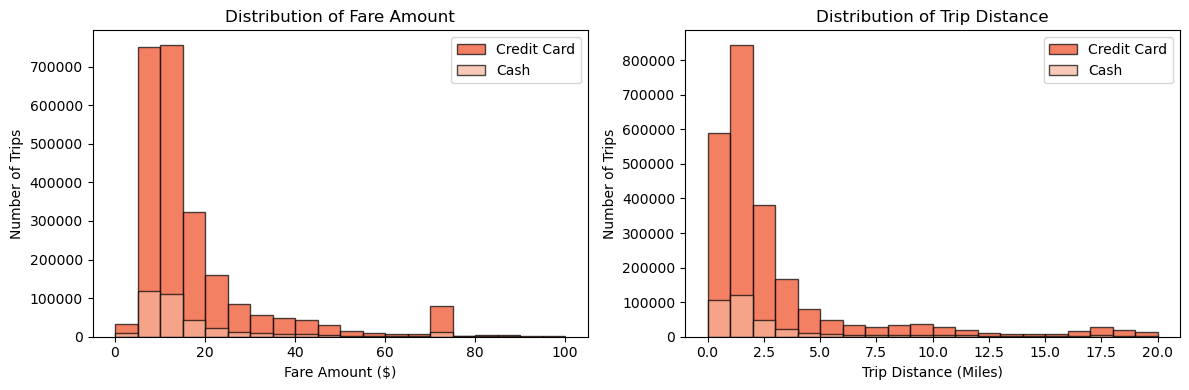

In [16]:
plt.figure(figsize=(12, 4))

# Fare Amount Distribution
plt.subplot(1, 2, 1)

plt.hist(
    df[df["payment_type"] == "Credit Card"]["fare_amount"],
    bins=np.arange(0, 105, 5),
    alpha=0.7,
    label="Credit Card",
    color="#F04B23" ,
    edgecolor='k'
)

plt.hist(
    df[df["payment_type"] == "Cash"]["fare_amount"],
    bins=np.arange(0, 105, 5),
    alpha=0.7,
    label="Cash",
    edgecolor='k',
    color="#F6B49A" 

)

plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Fare Amount")
plt.legend()


# Trip Distance Distribution
plt.subplot(1, 2, 2)

plt.hist(
    df[df["payment_type"] == "Credit Card"]["trip_distance"],
    bins=np.arange(0, 21, 1),
    alpha=0.7,
    label="Credit Card",
    edgecolor='k',
    color="#F04B23" 

)

plt.hist(
    df[df["payment_type"] == "Cash"]["trip_distance"],
    bins=np.arange(0, 21, 1),
    alpha=0.7,
    label="Cash",
    edgecolor='k',
    color="#F6B49A" 

)

plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")
plt.legend()


plt.tight_layout()
plt.show()

Both fare amount and trip distance are right-skewed, with most observations concentrated in lower fare and shorter-distance ranges. Credit Card trips are more frequent than Cash trips across most ranges. Further statistical testing is required to determine whether the difference in fares between the two payment methods is statistically significant

In [17]:
df.groupby('payment_type').agg(
    {
        'fare_amount':['mean','std'],
        'trip_distance':['mean','std']
    }
)

fare_amount            trip_distance           
                    mean        std          mean        std
payment_type                                                
Cash           18.043191  19.072293      3.184662   5.682155
Credit Card    17.857234  16.623199      3.221932  46.832584

Insights

1. Fare Amount

Credit Card is used for a much larger number of trips, especially in the lower fare ranges. However, Cash trips have a slightly higher average fare ($18.04) compared to Credit Card trips ($17.86).

2. Trip Distance

Most trips are short-distance, and Credit Card is the dominant payment method in these trips. However, the average trip distance is almost the same for both payment methods (Credit Card: 3.22 miles, Cash: 3.18 miles).

Overall Insight

Credit Card is the most frequently used payment method, but the average fare and trip distance are very similar between Credit Card and Cash trips. This leads us to test whether the small difference in average fare is statistically significant.

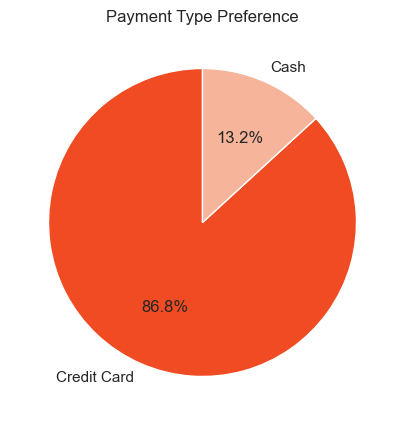

In [19]:
# Payment Type Preference

# Seaborn theme
sns.set_theme(style="white")

# Payment type counts
payment_counts = df["payment_type"].value_counts()

# Colors
colors = ["#F04B23", "#F6B49A"]

plt.figure(figsize=(7, 5))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Payment Type Preference")

plt.show()

Insight: Around 87%(approx.) of trips were paid by Credit Card compared with 13%(approx.) by Cash, showing that Credit Card is the clearly dominant payment method in the analyzed dataset


In [24]:
df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()

passenger_count
payment_type passenger_count                 
Cash         0.0                         3786
             1.0                       278606
             2.0                        55813
             3.0                        13838
             4.0                        11309
             5.0                         2612
             6.0                         1949
             8.0                            1
             9.0                            1
Credit Card  0.0                        19365
             1.0                      1934377
             2.0                       330869
             3.0                        72307
             4.0                        41806
             5.0                        14954
             6.0                         9937
             7.0                            1
             8.0                            5
             9.0                            2

As we can see in the above summary table there are some error in our datasets for example the passenger count 0 also have entries in the data sets that why we are going to remove the errors

In [23]:
passenger_df = df[
    (df["passenger_count"].notna()) &
    (df["passenger_count"].between(1, 6))
].copy()

passenger_df["passenger_count"] = (
    passenger_df["passenger_count"].astype(int)
)

In [29]:
passenger_count = (
    passenger_df
    .groupby(["payment_type", "passenger_count"])
    .size()
    .reset_index(name="trip_count")
)

passenger_count


,payment_type,passenger_count,trip_count
0,Cash,1,278606
1,Cash,2,55813
2,Cash,3,13838
3,Cash,4,11309
4,Cash,5,2612
5,Cash,6,1949
6,Credit Card,1,1934377
7,Credit Card,2,330869
8,Credit Card,3,72307
9,Credit Card,4,41806


Now for represnting the payment_type perference according to count we need to find the contribution for each passenger count

In [35]:

passenger_count["percentage"] = (
    passenger_count["trip_count"] /
    passenger_count["trip_count"].sum()
) * 100

passenger_count["percentage"] = (
    passenger_count["percentage"].round(1)
)

passenger_count

,payment_type,passenger_count,trip_count,total_trips,percentage,contiribution
0,Cash,1,278606,364127,10.1,10.063875
1,Cash,2,55813,364127,2.0,2.016091
2,Cash,3,13838,364127,0.5,0.499860
3,Cash,4,11309,364127,0.4,0.408507
4,Cash,5,2612,364127,0.1,0.094351
5,Cash,6,1949,364127,0.1,0.070402
6,Credit Card,1,1934377,2404250,69.9,69.874045
7,Credit Card,2,330869,2404250,12.0,11.951732
8,Credit Card,3,72307,2404250,2.6,2.611891
9,Credit Card,4,41806,2404250,1.5,1.510127


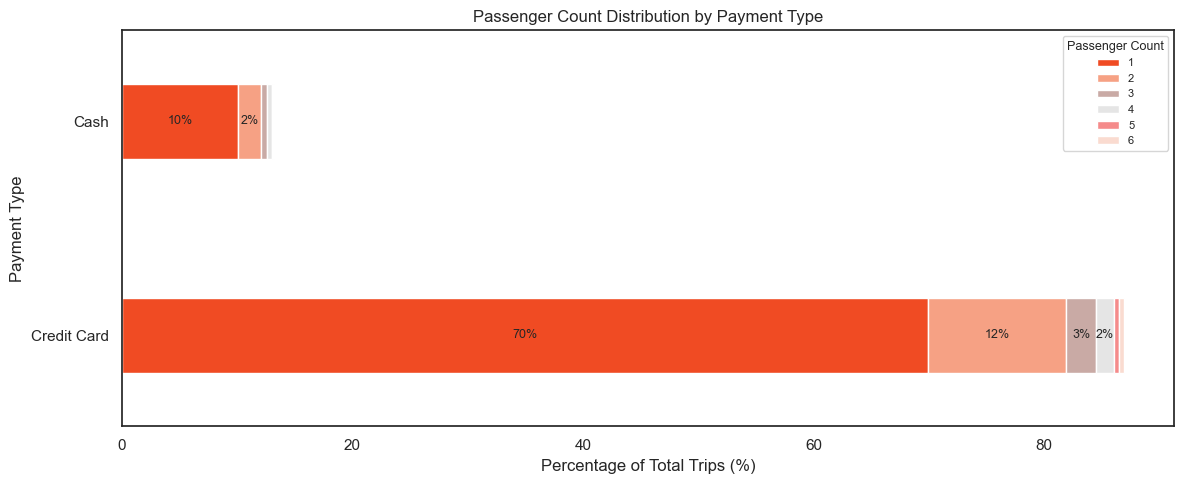

In [38]:
# Arrange payment types like reference chart
chart_data = chart_data.reindex(["Credit Card", "Cash"])

# Colors
colors = [
    "#F04B23",
    "#F6A184",
    "#C9AAA5",
    "#E5E5E5",
    "#F58B8B",
    "#FADBD0"
]

# Create stacked horizontal bar chart
ax = chart_data.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 5),
    color=colors,
    width=0.35
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 1 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Labels
plt.xlabel("Percentage of Total Trips (%)")
plt.ylabel("Payment Type")
plt.title("Passenger Count Distribution by Payment Type")

# IMPORTANT: Don't use plt.xlim(0, 100)

# Compact legend
plt.legend(
    title="Passenger Count",
    loc="upper right",
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.show()

Passenger Count & Payment Preference: Single-passenger trips dominate the dataset, contributing approximately 70% of all valid trips for Credit Card and 10% for Cash. Two-passenger trips form the next largest group, while trips with three or more passengers represent only a small proportion of total trips. Overall, Credit Card remains the dominant payment method across passenger-count groups.

## Hypothesis Testing: Credit Card vs Cash Fare Amount

### Business Question
Is there a statistically significant difference in the average fare amount between trips paid by Credit Card and Cash?

### Hypotheses

**Null Hypothesis (H₀):**  
There is no significant difference in the average fare amount between Credit Card and Cash trips.


**Alternative Hypothesis (H₁):**  
There is a significant difference in the average fare amount between Credit Card and Cash trips.

### Significance Level
alpha = 0.05

### Statistical Test
**Welch's Independent Two-Sample t-test**

### Why this test?
- We are comparing the mean fare amount of two independent groups: Credit Card and Cash.
- Fare amount is a numerical variable.
- The two groups have substantially different sample sizes.
- Welch's t-test does not require the two groups to have equal variances.

### Decision Rule
- If **p-value < 0.05** → Reject H₀.
- If **p-value ≥ 0.05** → Fail to reject H₀

In [ ]:
# Create two samples
credit_card = df[df["payment_type"] == "Credit Card"]["fare_amount"]
cash = df[df["payment_type"] == "Cash"]["fare_amount"]


# Perform Welch's Independent T-Test
t_stat, p_value = stats.ttest_ind(
    credit_card,
    cash,
    equal_var=False
)


# Print test results
print("T-Statistic:", round(t_stat, 2))
print("P-Value:", p_value)


# Significance level
alpha = 0.05


# Final Decision
if p_value < alpha:
    print("\nReject H0")
    print("->There is a statistically significant difference in the average fare amount between Credit Card and Cash trips.")
else:
    print("\nFail to Reject H0")
    print(" -> There is not enough evidence to conclude that the average fare amount differs significantly between Credit Card and Cash trips.")

T-Statistic: -5.6
P-Value: 2.1451953842695534e-08

Reject H0
There is a statistically significant difference in the average fare amount between Credit Card and Cash trips.
